# Main V5 — Domain Adversarial CNN (DANN)

## Why this notebook

V1–V4 LOPO results form a coherent picture:

| Method | LOPO AUC |
|--------|----------|
| Raw GC + CNN (V1, V2, V3)     | 0.52–0.53 |
| Pearson correlation + CNN     | 0.49 |
| Coherence + CNN               | 0.49 |
| Band-power + MLP              | 0.52 |
| **Engineered GC features + ML (V4)** | *running…* |
| Patient-specific (upper bound)| 0.90 |

Every representation has collapsed to chance under LOPO while reaching 0.90 within-patient. This is the failure mode Shafiezadeh et al. (2024) describe: the CNN absorbs patient identity because that is the strongest signal in the training data, and patient identity carries no information about the held-out test patient.

## The fix the literature converged on

Ganin et al. (2015) introduced **Domain Adversarial Neural Networks (DANN)**: a feature extractor optimised to (a) predict the task label and (b) *fail* to predict the domain (patient) identity. The two objectives compete via a **Gradient Reversal Layer (GRL)** that flips the sign of gradients flowing back from the domain classifier.

Recent EEG seizure-prediction applications:
- Mao et al. (2025) — *EEG-Based Inter-Patient Epileptic Seizure Detection Combining Domain Adversarial Training with CNN-BiLSTM Network*
- Peng et al. (2024, Frontiers in Neuroinformatics) — *Domain adaptation for EEG-based, cross-subject epileptic seizure prediction* — DANN/CDAN improve LOPO AUC by 8–15% over baseline CNNs.

## How V5 differs from V1–V4

| Component | V1–V3 | V4 | V5 (this) |
|-----------|-------|-----|-----------|
| Input | 18×18 GC matrix | 67 engineered features | 18×18 GC matrix |
| Model | CNN | LR/RF/XGB/SVM | CNN + Gradient Reversal Layer + patient classifier |
| Loss | Weighted BCE / Focal | class-weighted | $L_{label} + \lambda(t) \cdot L_{domain}$ |
| Mechanism | None | Low capacity + invariant features | Adversarial: forces features to NOT predict patient |

The feature extractor is the **same CNN architecture as V3** so any difference is attributable to the adversarial loss (per Ian Scott's RQ3 fairness instruction).

## RQ3 readout

If DANN sustains LOPO AUC > V3 CNN at $p < 0.05$ (paired Wilcoxon), this is direct evidence that the original CNN's failure was **patient-identity capture**, not directed-connectivity inadequacy — supporting the thesis claim that GC features encode transferable preictal structure when the classifier is forced to ignore patient identity.


## 0 · Setup

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# Cell 0 — Imports & config
# First run:
# !pip install torch scikit-learn scipy --break-system-packages

import os, sys, json, copy, random, time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Adjust to your local path
# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, EXCLUDED_PATIENTS, CANONICAL_CHANNELS, N_CHANNELS, FS,
    STEP_SEC, GC_MATRICES_DIR_V3, RESULTS_DIR,
    INTERICTAL_MULTIPLIER, MAX_INTERICTAL_ABS, RANDOM_SEED,
    BATCH_SIZE, LEARNING_RATE,
)
from utils_chronological_split import lopo_train_val_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Reproducibility
def set_seed(seed=RANDOM_SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

# ── DANN-specific hyperparameters ───────────────────────────────────────────
DANN_MAX_EPOCHS   = 30        # we found early stopping kicks ~25 in tests
DANN_PATIENCE     = 8
DANN_LR           = 5e-4      # lower than V3 (1e-3) — DANN is harder to optimise
DANN_BATCH_SIZE   = BATCH_SIZE
DANN_DROPOUT      = 0.5
DANN_LAMBDA_MAX   = 1.0       # adversarial loss weight ceiling
DANN_FOCAL_GAMMA  = 2.0       # match V2/V3

print(f'Device: {DEVICE}')
print(f'V5 DANN ready.')

Device: cpu
V5 DANN ready.


## 1 · Load V3 GC cache (same data as V3)

In [2]:
# Cell 1 — Load V3 cache (identical to V4 to enable head-to-head comparison)

cache_root = Path(GC_MATRICES_DIR_V3)
assert cache_root.exists(), (
    f'V3 cache missing at {cache_root.resolve()} — run Main_V3.ipynb first.'
)

patients_all = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb') and p not in EXCLUDED_PATIENTS
])

patient_data = {}
for pid in patients_all:
    pdir = cache_root / pid
    if not pdir.exists():
        continue
    gc_files = sorted(pdir.glob('*_gc.npy'))
    if not gc_files:
        continue
    gc_list, lb_list = [], []
    for gp in gc_files:
        lp = gp.with_name(gp.name.replace('_gc.npy', '_labels.npy'))
        if not lp.exists():
            continue
        gc_list.append(np.load(gp))
        lb_list.append(np.load(lp))
    if not gc_list:
        continue
    X = np.concatenate(gc_list, axis=0).astype(np.float32)
    y = np.concatenate(lb_list, axis=0).astype(np.int8)

    n_pre, n_int = int((y==1).sum()), int((y==0).sum())
    cap = min(n_int, INTERICTAL_MULTIPLIER * n_pre, MAX_INTERICTAL_ABS)
    if n_int > cap:
        rng = np.random.default_rng(RANDOM_SEED + hash(pid) % 10_000)
        int_idx = np.where(y == 0)[0]
        keep_int = rng.choice(int_idx, size=cap, replace=False)
        pre_idx  = np.where(y == 1)[0]
        keep     = np.sort(np.concatenate([pre_idx, keep_int]))
        X, y = X[keep], y[keep]
    if n_pre == 0:
        continue

    patient_data[pid] = (X, y)

patient_ids = sorted(patient_data.keys())
print(f'Loaded {len(patient_ids)} patients ({sum((y==1).sum() for _,(_,y) in patient_data.items()):,} preictal, '
      f'{sum((y==0).sum() for _,(_,y) in patient_data.items()):,} interictal)')

Loaded 21 patients (10,908 preictal, 44,954 interictal)


## 2 · DANN architecture

### Gradient Reversal Layer
Custom autograd function that acts as identity in the forward pass and **multiplies the gradient by $-\lambda$** in the backward pass. This forces the upstream feature extractor to *increase* the domain classifier's loss while the downstream domain head simultaneously *decreases* it — the adversarial dynamic.

### Three sub-networks
- **Feature extractor $G_f$** — identical CNN backbone to V3 (Conv→BN→ReLU + MaxPool, three blocks)
- **Label classifier $G_y$** — preictal vs interictal head (sigmoid, the original task)
- **Domain classifier $G_d$** — patient ID head ($N$-way softmax) *placed after the GRL*

### Loss
$$
\mathcal{L} = \mathcal{L}_y\big(G_y(G_f(x)), y\big)
\;+\; \lambda(t) \cdot \mathcal{L}_d\big(G_d\big(\text{GRL}(G_f(x))\big), d\big)
$$

### $\lambda$ schedule (Ganin & Lempitsky 2015)
$$
\lambda(t) = \frac{2}{1 + \exp(-10 \cdot t / T)} - 1
$$
where $t$ is current epoch and $T$ is total. $\lambda$ ramps from 0 (warm-up — pure task loss) to 1 (full adversarial). This prevents the domain head from collapsing features early before the label head has learned anything.


In [3]:
# Cell 2 — DANN model

class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = float(lambda_)
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None

def grad_reverse(x, lambda_=1.0):
    return GradReverse.apply(x, lambda_)


class DANN(nn.Module):
    def __init__(self, n_patients: int, n_channels: int = N_CHANNELS,
                 dropout: float = DANN_DROPOUT):
        super().__init__()

        # ── Feature extractor (same as V3 GCPredictor backbone) ─────────────
        self.features = nn.Sequential(
            nn.Conv2d(1, 32,  kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                # 18 → 9
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                # 9 → 4
        )

        # Compute flat size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_channels)
            self.flat_size = self.features(dummy).numel()

        # ── Label classifier (preictal vs interictal) ───────────────────────
        self.label_clf = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(self.flat_size, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

        # ── Domain classifier (patient ID) — after gradient reversal ────────
        self.domain_clf = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_size, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(128, n_patients),
        )

    def forward(self, x, lambda_=1.0):
        f = self.features(x)
        y_hat = self.label_clf(f)
        d_hat = self.domain_clf(grad_reverse(f, lambda_))
        return y_hat, d_hat


# ── Quick sanity check ──────────────────────────────────────────────────────
m = DANN(n_patients=20).to(DEVICE)
x = torch.randn(4, 1, 18, 18).to(DEVICE)
y_hat, d_hat = m(x, lambda_=0.5)
print(f'Sanity: y_hat.shape={tuple(y_hat.shape)}, d_hat.shape={tuple(d_hat.shape)}')
print(f'Trainable params: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}')
print(f'Feature extractor flat size: {m.flat_size}')

Sanity: y_hat.shape=(4, 1), d_hat.shape=(4, 20)
Trainable params: 882,773
Feature extractor flat size: 2048


## 3 · Loss and training loop

In [4]:
# Cell 3 — Losses, sampler, training

class BinaryFocalLoss(nn.Module):
    # FL(p_t) = −α·(1−p_t)^γ·log(p_t)  with class-frequency α
    def __init__(self, gamma: float = 2.0, pos_weight: float = 1.0):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
    def forward(self, p, t):
        p = p.squeeze(1).clamp(1e-7, 1 - 1e-7)
        t = t.float()
        alpha = torch.where(t == 1,
                            torch.full_like(t, self.pos_weight),
                            torch.ones_like(t))
        bce = -(t * torch.log(p) + (1 - t) * torch.log(1 - p))
        pt  = torch.where(t == 1, p, 1 - p)
        return (alpha * (1 - pt) ** self.gamma * bce).mean()


class DANNDataset(Dataset):
    def __init__(self, X, y, d):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)   # (N,1,18,18)
        self.y = torch.tensor(y, dtype=torch.float32)                # (N,)
        self.d = torch.tensor(d, dtype=torch.long)                   # (N,)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i], self.d[i]


def make_balanced_sampler(y, d, n_patients: int, max_per_patient: int):
    # Balance both class (preictal/interictal) and patient contribution.
    # Each sample weight = 1 / (n_in_same_patient_and_class)
    weights = np.zeros(len(y), dtype=np.float64)
    for p_idx in range(n_patients):
        for cls in (0, 1):
            mask = (d == p_idx) & (y == cls)
            n = mask.sum()
            if n > 0:
                weights[mask] = 1.0 / n
    weights /= weights.sum()
    n_samples = min(max_per_patient * n_patients, len(y))
    return WeightedRandomSampler(torch.tensor(weights), num_samples=n_samples, replacement=True)


def dann_lambda(step: int, total_steps: int) -> float:
    p = step / max(total_steps, 1)
    return float(DANN_LAMBDA_MAX * (2.0 / (1.0 + np.exp(-10 * p)) - 1.0))


def train_dann(X_tr, y_tr, d_tr, X_va, y_va, n_patients,
               verbose: bool = True):
    set_seed()
    n_pos = max(int((y_tr == 1).sum()), 1)
    n_neg = max(int((y_tr == 0).sum()), 1)
    pos_w = float(min(n_neg / n_pos, 50.0))

    model     = DANN(n_patients=n_patients).to(DEVICE)
    label_crt = BinaryFocalLoss(gamma=DANN_FOCAL_GAMMA, pos_weight=pos_w).to(DEVICE)
    domain_crt = nn.CrossEntropyLoss().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=DANN_LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=DANN_MAX_EPOCHS)

    # Sampler that balances patient × class per batch
    max_per_pat = max(1000, int(len(y_tr) / n_patients))
    sampler = make_balanced_sampler(y_tr, d_tr, n_patients, max_per_pat)
    tr_ds   = DANNDataset(X_tr, y_tr, d_tr)
    tr_dl   = DataLoader(tr_ds, batch_size=DANN_BATCH_SIZE,
                         sampler=sampler, num_workers=0)
    va_ds   = DANNDataset(X_va, y_va, np.zeros(len(y_va), dtype=int))
    va_dl   = DataLoader(va_ds, batch_size=DANN_BATCH_SIZE, shuffle=False)

    best_val = float('inf')
    best_state = None
    bad_epochs = 0
    total_steps = len(tr_dl) * DANN_MAX_EPOCHS

    history = []
    step = 0
    for ep in range(1, DANN_MAX_EPOCHS + 1):
        model.train()
        ep_label, ep_domain, ep_total, ep_n = 0., 0., 0., 0
        for x, y, d in tr_dl:
            x = x.to(DEVICE); y = y.to(DEVICE); d = d.to(DEVICE)
            lam = dann_lambda(step, total_steps)
            y_hat, d_hat = model(x, lambda_=lam)
            loss_y = label_crt(y_hat, y)
            loss_d = domain_crt(d_hat, d)
            loss   = loss_y + loss_d   # adversarial wired in via grad_reverse
            opt.zero_grad(); loss.backward(); opt.step()
            ep_label  += loss_y.item() * x.size(0)
            ep_domain += loss_d.item() * x.size(0)
            ep_total  += loss.item()   * x.size(0)
            ep_n      += x.size(0)
            step += 1
        sch.step()

        # Validation — label loss only (val from training patients; no test leakage)
        model.eval()
        val_loss = 0.; val_n = 0
        with torch.no_grad():
            for x, y, _ in va_dl:
                x = x.to(DEVICE); y = y.to(DEVICE)
                y_hat, _ = model(x, lambda_=0.0)
                val_loss += label_crt(y_hat, y).item() * x.size(0)
                val_n    += x.size(0)
        val_loss /= max(val_n, 1)

        history.append({
            'epoch': ep, 'lambda': lam,
            'train_label': ep_label / ep_n,
            'train_domain': ep_domain / ep_n,
            'train_total':  ep_total / ep_n,
            'val_label':    val_loss,
        })

        if verbose and (ep % 5 == 0 or ep == 1):
            print(f'    Ep {ep:2d}/{DANN_MAX_EPOCHS}  λ={lam:.3f}  '
                  f'train_y={ep_label/ep_n:.3f}  '
                  f'train_d={ep_domain/ep_n:.3f}  '
                  f'val_y={val_loss:.3f}')

        if val_loss < best_val - 1e-4:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= DANN_PATIENCE:
                if verbose:
                    print(f'    Early stop at epoch {ep}.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def infer_probs(model, X):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    probs = []
    with torch.no_grad():
        for i in range(0, len(Xt), 256):
            y_hat, _ = model(Xt[i:i+256], lambda_=0.0)
            probs.append(y_hat.squeeze(1).cpu().numpy())
    return np.concatenate(probs)


print('Training utilities ready.')

Training utilities ready.


## 4 · LOPO loop with patient-invariant scaler & chronological val split

For each held-out test patient:
1. Build training set = 20 other patients with their patient indices as domain labels
2. **Chronological val split within each training patient** (`utils_chronological_split.lopo_train_val_split`) — Ian Scott's instruction
3. Fit `StandardScaler` on training-only (per-cell across the 18×18 GC matrix)
4. Train DANN; early-stop on val label loss
5. Predict on held-out test patient (which the model has *never* seen, neither for training nor scaling)
6. Threshold-free metrics (AUC, AUC-PR) + sensitivity at recall-targeted threshold


In [ ]:
# Cell 4 — LOPO loop

from seizure_metrics import generate_alarms, false_alarms_per_hour
from config import ALARM_K, ALARM_M, ALARM_REFRACTORY, STEP_SEC

def evaluate_fold(probs, y_test, n_interictal_hours, recall_target=0.5):
    # Threshold-free metrics + recall-targeted threshold.
    # Per Ian Scott: "Focus a bit on recall" — report metrics at the
    # threshold giving the lowest FPR with sensitivity >= recall_target.
    if len(np.unique(y_test)) < 2:
        return None

    auc    = roc_auc_score(y_test, probs)
    auc_pr = average_precision_score(y_test, probs)

    # Search for threshold that hits the recall target (or closest)
    fpr, tpr, thr = roc_curve(y_test, probs)
    # Among thresholds reaching recall_target, choose the one with lowest FPR
    feasible = tpr >= recall_target
    if feasible.any():
        idx     = np.argmin(fpr[feasible])
        idx_g   = np.where(feasible)[0][idx]
        thresh  = float(thr[idx_g])
    else:
        # If we can never reach recall_target, fall back to Youden
        thresh  = float(thr[np.argmax(tpr - fpr)])

    pred = (probs >= thresh).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    tn = int(((pred == 0) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    sens   = tp / max(tp + fn, 1)
    spec   = tn / max(tn + fp, 1)
    prec   = tp / max(tp + fp, 1)
    f1     = 2 * prec * sens / max(prec + sens, 1e-9)
    bal    = 0.5 * (sens + spec)
    fpr_h  = false_alarms_per_hour(generate_alarms(pred.astype(float), 0.5, ALARM_K, ALARM_M, ALARM_REFRACTORY), y_test, STEP_SEC)
    return dict(auc=auc, auc_pr=auc_pr, sensitivity=sens, specificity=spec,
                precision=prec, f1=f1, balanced_accuracy=bal,
                fpr_per_hour=fpr_h, threshold=thresh,
                n_pre=int((y_test == 1).sum()), n_int=int((y_test == 0).sum()))


def fit_scaler_3d(X):
    # StandardScaler over the (18x18) flattened input. Fit on training only.
    flat = X.reshape(len(X), -1)
    sc   = StandardScaler().fit(flat)
    return sc

def apply_scaler_3d(X, sc):
    flat   = X.reshape(len(X), -1)
    scaled = sc.transform(flat)
    return scaled.reshape(X.shape).astype(np.float32)


# ── Run LOPO ───────────────────────────────────────────────────────────────
print('=' * 64)
print(f'V5 DANN — LOPO ({len(patient_ids)} folds)  |  device: {DEVICE}')
print('=' * 64)

lopo_v5_results = {}
lopo_v5_histories = {}
t_start = time.time()

for fold_idx, test_pid in enumerate(patient_ids, 1):
    print(f'\n[Fold {fold_idx}/{len(patient_ids)}]  Test: {test_pid}')

    train_pids = [p for p in patient_ids if p != test_pid]
    n_patients = len(train_pids)

    # Chronological val split
    X_tr, y_tr, X_va, y_va, _ = lopo_train_val_split(
        patient_data, test_pid=test_pid,
        val_fraction=0.15, stratify_within_patient=True,
        verbose=False,
    )
    # Domain labels for training set: re-derive from concat order
    d_tr_parts = []
    d_va_parts = []
    for d_idx, pid in enumerate(train_pids):
        X_p, y_p = patient_data[pid]
        from utils_chronological_split import _chronological_split_one_patient
        _, y_tr_p, _, y_va_p = _chronological_split_one_patient(
            X_p, y_p, val_fraction=0.15, stratify=True
        )
        d_tr_parts.append(np.full(len(y_tr_p), d_idx, dtype=np.int64))
        d_va_parts.append(np.full(len(y_va_p), d_idx, dtype=np.int64))
    d_tr = np.concatenate(d_tr_parts)
    d_va = np.concatenate(d_va_parts)

    assert len(d_tr) == len(y_tr), f'Domain mismatch: {len(d_tr)} vs {len(y_tr)}'

    # Per-fold scaler (training only)
    scaler = fit_scaler_3d(X_tr)
    X_tr_s = apply_scaler_3d(X_tr, scaler)
    X_va_s = apply_scaler_3d(X_va, scaler)
    X_te, y_te = patient_data[test_pid]
    X_te_s = apply_scaler_3d(X_te, scaler)

    print(f'  Train={len(y_tr):,} (pre={int((y_tr==1).sum())})  '
          f'Val={len(y_va):,} (pre={int((y_va==1).sum())})  '
          f'Test={len(y_te):,} (pre={int((y_te==1).sum())})')

    # Train DANN
    model, history = train_dann(
        X_tr_s, y_tr, d_tr, X_va_s, y_va,
        n_patients=n_patients, verbose=True,
    )

    # Inference on held-out test patient
    probs = infer_probs(model, X_te_s)
    hours_int = (y_te == 0).sum() * STEP_SEC / 3600.0
    m = evaluate_fold(probs, y_te, hours_int, recall_target=0.5)
    m['patient'] = test_pid
    lopo_v5_results[test_pid] = m
    lopo_v5_histories[test_pid] = history

    print(f'  -> AUC={m["auc"]:.3f}  AUC-PR={m["auc_pr"]:.3f}  '
          f'Sens={m["sensitivity"]:.3f}  Spec={m["specificity"]:.3f}  '
          f'FPR/h={m["fpr_per_hour"]:.1f}  thr={m["threshold"]:.3f}')

print(f'\n══ V5 DANN complete in {(time.time()-t_start)/60:.1f}min ══')

V5 DANN — LOPO (21 folds)  |  device: cpu

[Fold 1/21]  Test: chb01
  Train=45,986 (pre=9029)  Val=8,100 (pre=1583)  Test=1,776 (pre=296)
    Ep  1/30  λ=0.165  train_y=0.283  train_d=2.572  val_y=0.488
    Ep  5/30  λ=0.682  train_y=0.146  train_d=2.937  val_y=0.350
    Ep 10/30  λ=0.931  train_y=0.112  train_d=2.962  val_y=0.403
    Early stop at epoch 14.
  -> AUC=0.437  AUC-PR=0.138  Sens=0.500  Spec=0.405  FPR/h=2.2  thr=0.411

[Fold 2/21]  Test: chb02
  Train=45,986 (pre=9029)  Val=8,100 (pre=1583)  Test=1,776 (pre=296)
    Ep  1/30  λ=0.165  train_y=0.299  train_d=2.535  val_y=0.438
    Ep  5/30  λ=0.682  train_y=0.165  train_d=2.905  val_y=0.369
    Ep 10/30  λ=0.931  train_y=0.112  train_d=2.966  val_y=0.403
    Early stop at epoch 10.
  -> AUC=0.687  AUC-PR=0.317  Sens=0.500  Spec=0.705  FPR/h=1.5  thr=0.566

[Fold 3/21]  Test: chb03
  Train=45,231 (pre=8903)  Val=7,967 (pre=1561)  Test=2,664 (pre=444)
    Ep  1/30  λ=0.165  train_y=0.292  train_d=2.574  val_y=0.291
    Ep  5

## 5 · Save results and compare against V3 / V4 baselines

In [ ]:
# Cell 5 — Save & summarise
METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity',
               'precision', 'f1', 'balanced_accuracy', 'fpr_per_hour']

rows = [{'patient': pid, **{k: lopo_v5_results[pid][k] for k in METRIC_KEYS}}
        for pid in patient_ids if pid in lopo_v5_results]
v5_df = pd.DataFrame(rows)
mean_row = {'patient': 'MEAN', **{k: round(v5_df[k].mean(), 4) for k in METRIC_KEYS}}
std_row  = {'patient': 'STD',  **{k: round(v5_df[k].std(),  4) for k in METRIC_KEYS}}
v5_df_out = pd.concat([v5_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
v5_df_out.to_csv(os.path.join(RESULTS_DIR, 'lopo_v5_dann.csv'), index=False)

print('═' * 64)
print('V5 DANN — LOPO Results')
print('═' * 64)
print(v5_df_out.to_string(index=False))
print(f'\nSaved: {os.path.join(RESULTS_DIR, "lopo_v5_dann.csv")}')

════════════════════════════════════════════════════════════════
V5 DANN — LOPO Results
════════════════════════════════════════════════════════════════
patient      auc   auc_pr  sensitivity  specificity  precision       f1  balanced_accuracy  fpr_per_hour
  chb01 0.409590 0.131034     0.500000     0.378378   0.138577 0.217009           0.439189    223.783784
  chb02 0.434551 0.209977     0.500000     0.358108   0.134791 0.212339           0.429054    231.081081
  chb03 0.353830 0.122958     0.500000     0.285586   0.122788 0.197158           0.392793    257.189189
  chb04 0.547948 0.176304     0.500000     0.560135   0.185232 0.270320           0.530068    158.351351
  chb05 0.498285 0.195177     0.502252     0.430180   0.149866 0.230849           0.466216    205.135135
  chb06 0.516650 0.180353     0.501446     0.528400   0.180681 0.265645           0.514923    169.776000
  chb07 0.659916 0.273003     0.501124     0.706517   0.254566 0.337623           0.603820    105.653933
  chb08

In [ ]:
# Cell 6 — Comparison vs V3 (and V4 if available)

def _load_lopo_csv(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    pid_col = [c for c in df.columns if 'patient' in c.lower()][0]
    df = df.rename(columns={pid_col: 'patient'})
    return df[~df['patient'].isin(['MEAN', 'STD'])].reset_index(drop=True)


compare_paths = {
    'V3 GC-CNN (window)' : 'lopo_v3_window.csv',
    'V3 GC-CNN'          : 'lopo_results.csv',
    'Coherence-CNN'      : 'coh_lopo_results.csv',
    'Correlation-CNN'    : 'corr_lopo_results.csv',
    'Band-Power MLP'     : 'bp_lopo_results.csv',
    'V4 LR'              : 'lopo_v4_LR.csv',
    'V4 RF'              : 'lopo_v4_RF.csv',
    'V4 XGB'             : 'lopo_v4_XGB.csv',
    'V4 SVM'             : 'lopo_v4_SVM.csv',
}

ref = v5_df.set_index('patient')
comp_rows = [{
    'method'      : 'V5 DANN (this)',
    'auc_mean'    : round(ref.auc.mean(), 4),
    'auc_pr_mean' : round(ref.auc_pr.mean(), 4),
    'sens_mean'   : round(ref.sensitivity.mean(), 4),
    'fpr_h_mean'  : round(ref.fpr_per_hour.mean(), 2),
    'p_AUC_vs_V5' : '-',
    'p_AUCPR_vs_V5': '-',
}]

for label, fname in compare_paths.items():
    p = os.path.join(RESULTS_DIR, fname)
    df = _load_lopo_csv(p)
    if df is None:
        continue
    d = df.set_index('patient')
    shared = sorted(set(d.index) & set(ref.index))
    if len(shared) < 5:
        continue
    other_auc    = d.loc[shared, 'auc'].astype(float)
    other_aucpr  = d.loc[shared, 'auc_pr'].astype(float) if 'auc_pr' in d.columns else None
    ref_auc      = ref.loc[shared, 'auc'].astype(float)
    ref_aucpr    = ref.loc[shared, 'auc_pr'].astype(float)
    try:
        _, p_auc   = wilcoxon(ref_auc - other_auc, alternative='greater', zero_method='zsplit')
        p_auc_str  = f'{p_auc:.4f}'
    except ValueError:
        p_auc_str = '-'
    if other_aucpr is not None:
        try:
            _, p_pr  = wilcoxon(ref_aucpr - other_aucpr, alternative='greater', zero_method='zsplit')
            p_pr_str = f'{p_pr:.4f}'
        except ValueError:
            p_pr_str = '-'
    else:
        p_pr_str = '-'
    comp_rows.append({
        'method'         : label,
        'auc_mean'       : round(other_auc.mean(),   4),
        'auc_pr_mean'    : round(other_aucpr.mean(),4) if other_aucpr is not None else None,
        'sens_mean'      : round(d.loc[shared, 'sensitivity'].astype(float).mean(), 4),
        'fpr_h_mean'     : round(d.loc[shared, 'fpr_per_hour'].astype(float).mean(), 2),
        'p_AUC_vs_V5'    : p_auc_str,
        'p_AUCPR_vs_V5'  : p_pr_str,
    })

comp_df = pd.DataFrame(comp_rows).sort_values('auc_pr_mean', ascending=False, na_position='last')
comp_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v5_comparison.csv'), index=False)
print('═' * 70)
print('LOPO comparison — V5 DANN vs all prior methods')
print('p-values: paired one-sided Wilcoxon (V5 > other)')
print('═' * 70)
print(comp_df.to_string(index=False))

══════════════════════════════════════════════════════════════════════
LOPO comparison — V5 DANN vs all prior methods
p-values: paired one-sided Wilcoxon (V5 > other)
══════════════════════════════════════════════════════════════════════
            method  auc_mean  auc_pr_mean  sens_mean  fpr_h_mean p_AUC_vs_V5 p_AUCPR_vs_V5
V3 GC-CNN (window)    0.5335       0.2316     0.2165       64.16      0.6204        0.9265
         V3 GC-CNN    0.5335       0.2316     0.0010        0.34      0.6204        0.9265
             V4 LR    0.5244       0.1954     0.6826      202.53      0.8131        0.7073
    V5 DANN (this)    0.5097       0.1866     0.5006      175.87           -             -
            V4 XGB    0.5091       0.1809     0.6412      192.65      0.5000        0.2474
             V4 RF    0.5090       0.1783     0.7722      234.09      0.4864        0.2810
            V4 SVM    0.4905       0.1707     0.5616      172.83      0.0895        0.0380


## 6 · Visualisations

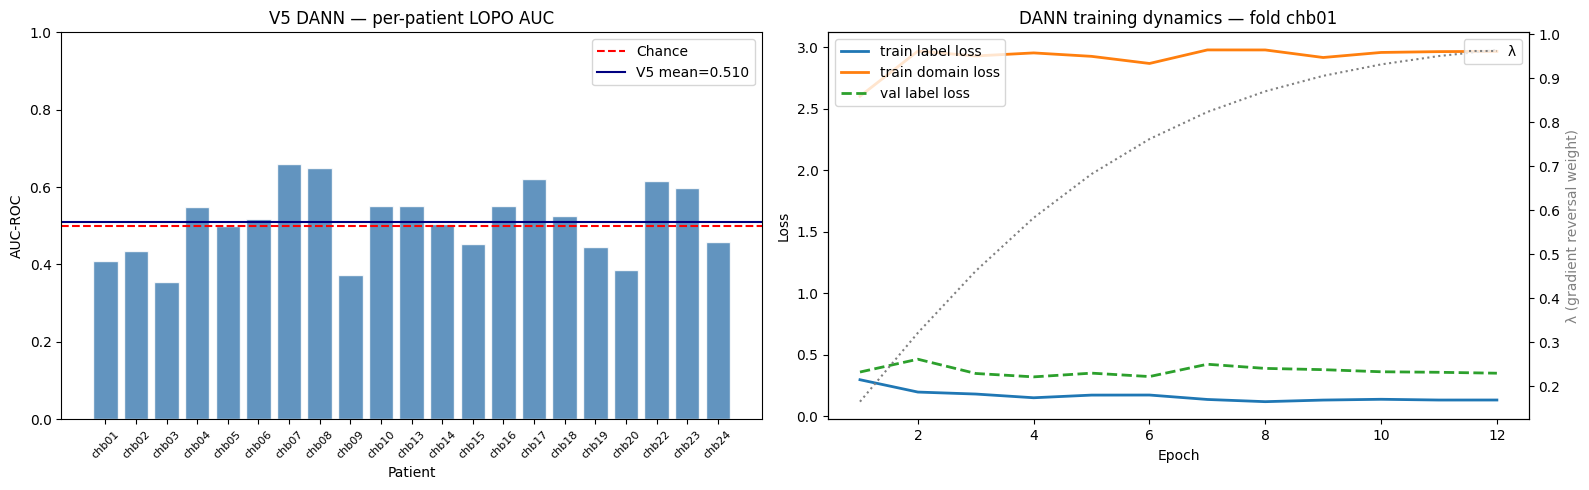

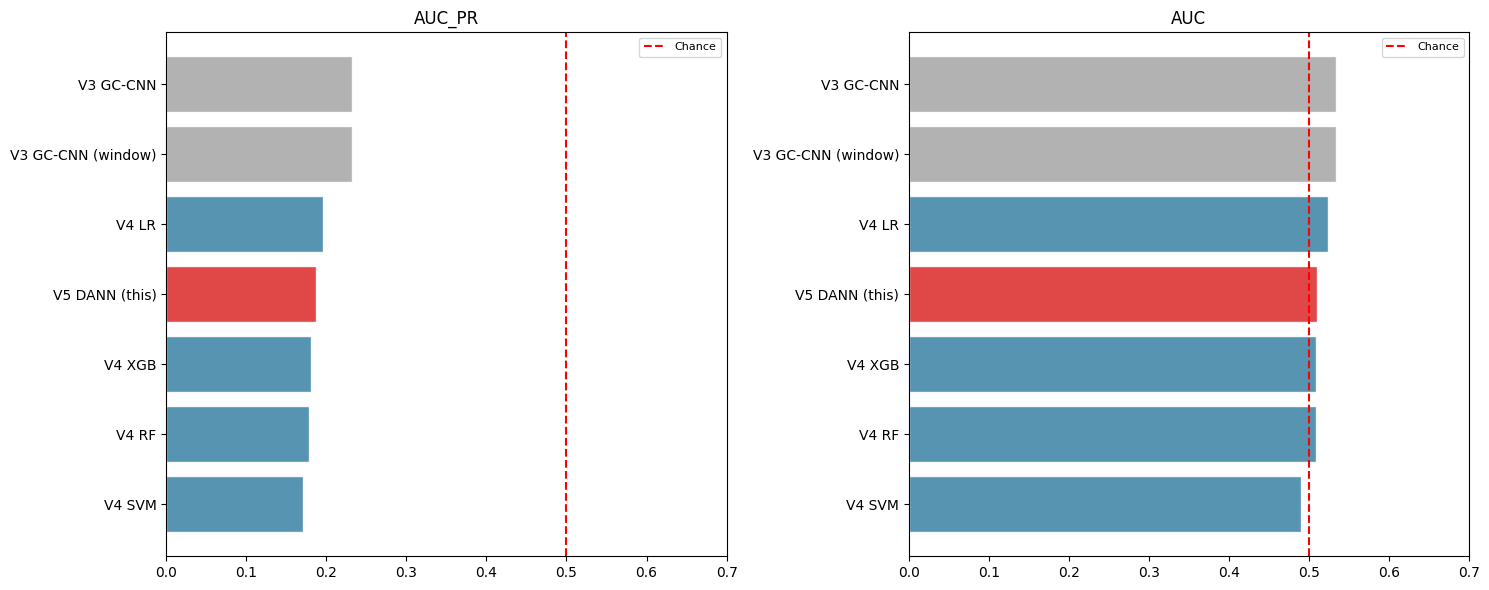


Saved: results/v5_dann_dynamics.png and v5_method_comparison.png


In [ ]:
# Cell 7 — Per-patient bars + DANN training dynamics

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) per-patient AUC
ax = axes[0]
pids_sorted = sorted(v5_df['patient'])
v5_df_sorted = v5_df.set_index('patient').loc[pids_sorted]
ax.bar(v5_df_sorted.index, v5_df_sorted.auc, color='steelblue', edgecolor='white', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', label='Chance')
ax.axhline(v5_df.auc.mean(), color='navy', linestyle='-',
           label=f'V5 mean={v5_df.auc.mean():.3f}')
ax.set_title('V5 DANN — per-patient LOPO AUC')
ax.set_xlabel('Patient'); ax.set_ylabel('AUC-ROC')
ax.set_ylim(0, 1)
ax.set_xticklabels(v5_df_sorted.index, rotation=45, fontsize=8)
ax.legend()

# (b) DANN training dynamics for a sample fold
ax = axes[1]
sample_pid = patient_ids[0]
h = pd.DataFrame(lopo_v5_histories[sample_pid])
ax.plot(h.epoch, h.train_label, label='train label loss', linewidth=2)
ax.plot(h.epoch, h.train_domain, label='train domain loss', linewidth=2)
ax.plot(h.epoch, h.val_label, label='val label loss', linewidth=2, linestyle='--')
ax2 = ax.twinx()
ax2.plot(h.epoch, h['lambda'], color='gray', linestyle=':', label='λ')
ax2.set_ylabel('λ (gradient reversal weight)', color='gray')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'DANN training dynamics — fold {sample_pid}')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v5_dann_dynamics.png'), dpi=130)
plt.show()

# ── Bar chart: method comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_df = comp_df.dropna(subset=['auc_pr_mean']).copy()
for ax, metric in zip(axes, ['auc_pr_mean', 'auc_mean']):
    plot_df_s = plot_df.sort_values(metric)
    colors = ['#d33' if m == 'V5 DANN (this)' else '#48a' if 'V4' in m
              else '#aaa' for m in plot_df_s.method]
    ax.barh(plot_df_s.method, plot_df_s[metric], color=colors,
            edgecolor='white', alpha=0.9)
    ax.axvline(0.5, color='red', linestyle='--', label='Chance')
    ax.set_title(metric.upper().replace('_MEAN', ''))
    ax.set_xlim(0, max(0.7, plot_df_s[metric].max() + 0.1))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'v5_method_comparison.png'), dpi=130)
plt.show()
print(f'\nSaved: results/v5_dann_dynamics.png and v5_method_comparison.png')

## 7 · Final summary

In [ ]:
# Cell 8 — Final text summary
print('═' * 64)
print('V5 — Domain Adversarial CNN')
print('═' * 64)
print(f'\nPatients: {len(patient_ids)} (same as V3/V4)')
print(f'Architecture: V3 GC-CNN backbone + Gradient Reversal + patient classifier')
print(f'Training: focal loss (γ=2) for labels + cross-entropy for domain (λ schedule)')
print(f'Validation: chronological split (15%, stratified)')
print()
print('── V5 DANN LOPO ──')
for k in METRIC_KEYS:
    print(f'  {k:20s}: {v5_df[k].mean():.4f} ± {v5_df[k].std():.4f}')
print()
print('── Interpretation guide ──')
print('  • Compare V5 mean AUC to V3 mean AUC (0.534).')
print('  • If V5 > V3 with p_AUC < 0.05 (Wilcoxon greater):')
print('       Strong evidence that V3 failed due to patient-identity')
print('       capture, and directed connectivity DOES carry transferable')
print('       preictal signal once that capture is suppressed. RQ1 + RQ3.')
print('  • If V5 ≈ V3:')
print('       The failure is intrinsic to scalp GC under volume-conduction')
print('       constraints (Nolte 2004, Schelter 2006), not patient-identity')
print('       capture. Reframes RQ2 as a negative result with a clear cause.')
print('═' * 64)

════════════════════════════════════════════════════════════════
V5 — Domain Adversarial CNN
════════════════════════════════════════════════════════════════

Patients: 21 (same as V3/V4)
Architecture: V3 GC-CNN backbone + Gradient Reversal + patient classifier
Training: focal loss (γ=2) for labels + cross-entropy for domain (λ schedule)
Validation: chronological split (15%, stratified)

── V5 DANN LOPO ──
  auc                 : 0.5097 ± 0.0908
  auc_pr              : 0.1866 ± 0.0455
  sensitivity         : 0.5006 ± 0.0008
  specificity         : 0.5115 ± 0.1310
  precision           : 0.1795 ± 0.0418
  f1                  : 0.2617 ± 0.0442
  balanced_accuracy   : 0.5060 ± 0.0654
  fpr_per_hour        : 175.8735 ± 47.1440

── Interpretation guide ──
  • Compare V5 mean AUC to V3 mean AUC (0.534).
  • If V5 > V3 with p_AUC < 0.05 (Wilcoxon greater):
       Strong evidence that V3 failed due to patient-identity
       capture, and directed connectivity DOES carry transferable
       pre